# Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df = pd.read_csv("Hetauda_Dataset.csv")

# Inspect Dataset

In [3]:
print(df.head())
print(df.info())

   Grid_ID Study_Area  Year   Latitude  Longitude      NDVI      NDBI  \
0      0.0    Hetauda  2015  27.463222  84.893109  0.474166 -0.019999   
1      1.0    Hetauda  2015  27.467746  84.893109  0.394238 -0.024982   
2      2.0    Hetauda  2015  27.472269  84.893109  0.521904 -0.036725   
3      3.0    Hetauda  2015  27.476792  84.893109  0.566889 -0.089799   
4      4.0    Hetauda  2015  27.481315  84.893109  0.634904 -0.133764   

       NDWI   Elevation      Slope  Population  Builtup_Percent  \
0 -0.437773  353.297373   6.750480    0.044664         0.000000   
1 -0.385086  358.054450   4.113949    0.002351         0.000000   
2 -0.481180  373.730412   4.964584    7.359969         6.031324   
3 -0.512260  401.398967  10.575356    1.280329         0.000000   
4 -0.570997  472.417958  12.255977    0.000000         0.000000   

   Vegetation_Percent  Agriculture_Percent  Water_Percent  BareLand_Percent  \
0            3.001876            77.298311       0.000000         19.699812   


In [4]:
print(df["Water_Percent"].value_counts().head(20))

Water_Percent
0.000000     13185
0.844704        11
0.357483        11
1.501767        11
0.357644        10
11.608216        6
19.549140        6
0.026630         6
3.795732         6
9.026787         6
11.151952        6
1.653193         6
20.131217        6
15.785120        6
10.962822        6
2.229514         6
12.938092        6
16.727895        6
1.443932         6
54.803173        6
Name: count, dtype: int64


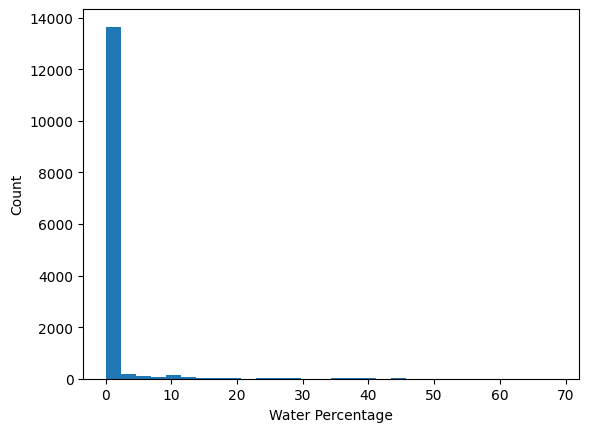

In [5]:
plt.hist(df["Water_Percent"], bins=30)
plt.xlabel("Water Percentage")
plt.ylabel("Count")
plt.show()

In [6]:
df["Total"] = (
    df["Builtup_Percent"] +
    df["Vegetation_Percent"] +
    df["Agriculture_Percent"] +
    df["Water_Percent"] +
    df["BareLand_Percent"]
)

print(df["Total"].describe())

count    1.437700e+04
mean     1.000000e+02
std      8.440474e-14
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: Total, dtype: float64


In [7]:
cols = [
    "Population",
    "Builtup_Percent",
    "Vegetation_Percent",
    "Agriculture_Percent",
    "Water_Percent"
]

print(df[cols].describe())

         Population  Builtup_Percent  Vegetation_Percent  Agriculture_Percent  \
count  14377.000000     14377.000000        14377.000000         14377.000000   
mean       5.763131         3.962690           65.637780            25.414844   
std       14.119226        11.442190           35.135596            30.370426   
min        0.000000         0.000000            0.000000             0.000000   
25%        0.004653         0.000000           32.167891             0.000000   
50%        1.343697         0.000000           79.906352             9.823282   
75%        6.699933         2.309440           99.285023            46.807168   
max      165.473364        97.405005          100.000000            99.732242   

       Water_Percent  
count   14377.000000  
mean        0.690261  
std         3.909117  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max        68.640978  


# Remove Missing Values

In [8]:
df = df.drop(columns=["Grid_ID"])
df = df.drop(columns=["Study_Area"])
df = df.drop(columns=["Total"])

In [9]:
df.groupby("Year")["LST"].mean()

Year
2015    28.637912
2016    32.125783
2017    30.896822
2018    32.735659
2019    32.357641
2020    30.085121
2021    30.582045
2022    32.303114
2023    33.283109
2024    33.867396
2025    34.813797
Name: LST, dtype: float64

In [10]:
print(df.isnull().sum())

Year                   0
Latitude               0
Longitude              0
NDVI                   0
NDBI                   0
NDWI                   0
Elevation              0
Slope                  0
Population             0
Builtup_Percent        0
Vegetation_Percent     0
Agriculture_Percent    0
Water_Percent          0
BareLand_Percent       0
LST                    0
dtype: int64


In [11]:
df = df.dropna()

# Define Features

In [12]:
# Environment Variable
# NOTE: Year is included as a predictor (temporal feature per the task spec).
# Without it, RF has no way to learn the warming trend across 2015-2025 and
# cross-validation becomes unstable, since rows are ordered by year in blocks.
features = [
    "Year",
    "Latitude",
    "Longitude",
    "NDVI",
    "NDBI",
    "NDWI",
    "Elevation",
    "Slope",
    "Population",
    "Builtup_Percent",
    "Vegetation_Percent",
    "Agriculture_Percent",
    "Water_Percent",
    "BareLand_Percent"
]

In [13]:
# Target Variable
target = "LST"

# Prepare X and y

In [14]:
X = df[features]
y = df[target]

# Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest

In [16]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

# Predict

In [17]:
y_pred = rf.predict(X_test)

# Evaluation

### RMSE

In [18]:
rmse = np.sqrt(mean_squared_error(
    y_test,
    y_pred
))

### MAE

In [19]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

### R²

In [20]:
r2 = r2_score(
    y_test,
    y_pred
)

# Print Results

In [21]:
print("Random Forest Results")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.3f}")

Random Forest Results
RMSE : 0.92
MAE  : 0.66
R²   : 0.923


# Feature Importance

In [22]:
importance = pd.DataFrame({
    "Feature":features,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
10   Vegetation_Percent    0.356983
0                  Year    0.266184
4                  NDBI    0.118883
3                  NDVI    0.076719
5                  NDWI    0.045349
6             Elevation    0.037400
2             Longitude    0.030775
7                 Slope    0.022258
1              Latitude    0.019861
8            Population    0.010210
11  Agriculture_Percent    0.006486
13     BareLand_Percent    0.004175
9       Builtup_Percent    0.003709
12        Water_Percent    0.001005


# Plot Feature Importance

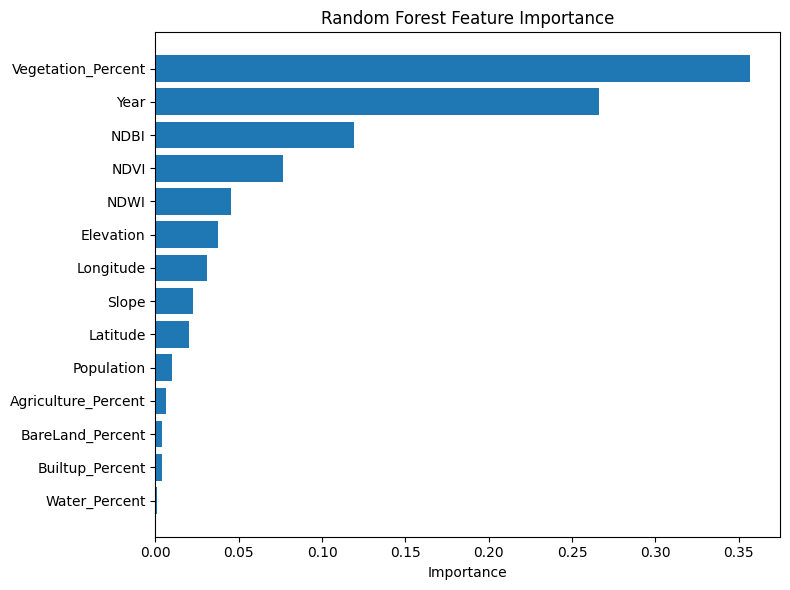

In [23]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Predicted vs Actual

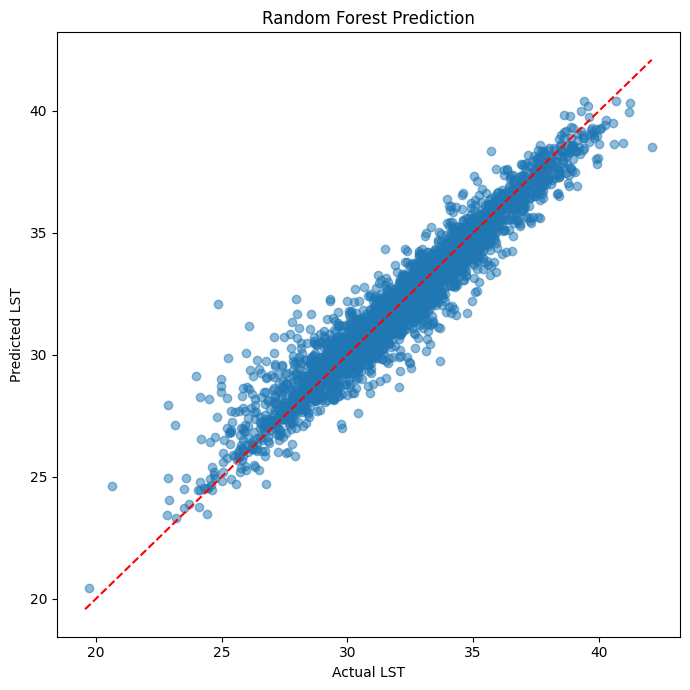

In [24]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Random Forest Prediction")
plt.tight_layout()
plt.show()

# Residual Plot

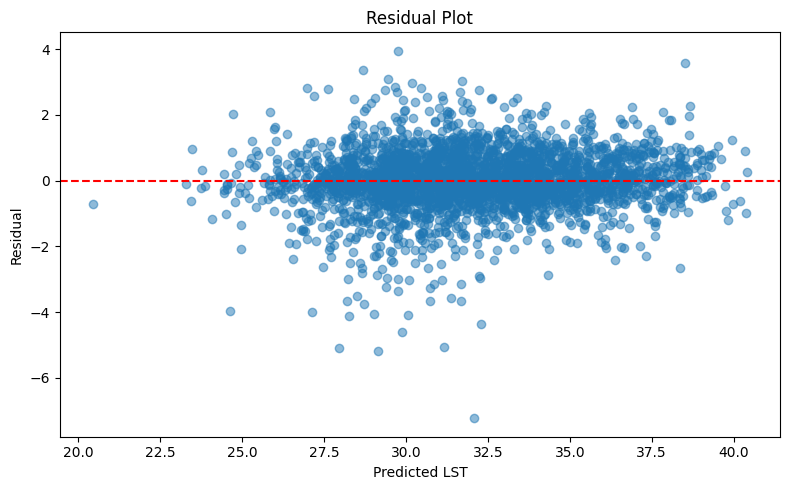

In [25]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted LST")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

# Further RF Diagnostics

### Train vs Test R² (overfitting check)

In [26]:
train_r2 = rf.score(X_train, y_train)
test_r2 = rf.score(X_test, y_test)

print(f"Train R² : {train_r2:.3f}")
print(f"Test  R² : {test_r2:.3f}")
print(f"Gap      : {train_r2 - test_r2:.3f}")

Train R² : 0.989
Test  R² : 0.923
Gap      : 0.066


#### 5-Fold Cross-Validation (is the 0.92 score stable?)\n\n**Important:** rows in this dataset are ordered by `Year` in contiguous blocks (all 2015 rows, then all 2016, etc.). Default `cv=5` in `cross_val_score` does **not** shuffle, so each fold would hold out a specific block of years — that's an extrapolation test, not a fair validation, and gives wildly unstable scores. Use a shuffled `KFold` instead.

In [27]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X, y,
    cv=cv,
    scoring="r2"
)

print("CV R² scores:", np.round(cv_scores, 3))
print(f"Mean CV R²: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")

CV R² scores: [0.923 0.916 0.924 0.92  0.925]
Mean CV R²: 0.922  (+/- 0.003)


#### Spatial Pattern of Residuals\n\nUHI errors are often not random in space — plotting residuals on Lat/Lon shows whether the model systematically under- or over-predicts in certain parts of the city.

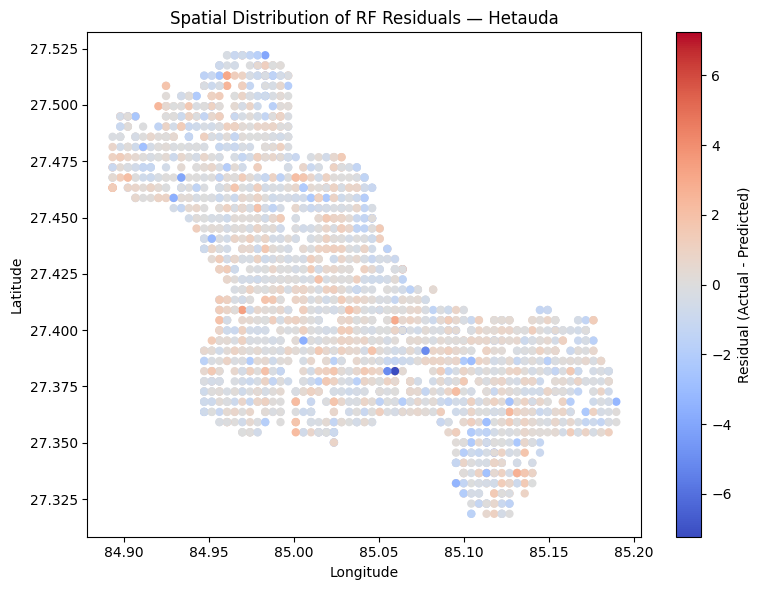

In [28]:
test_coords = X_test[["Latitude", "Longitude"]].copy()
test_coords["Residual"] = (y_test - y_pred).values

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    test_coords["Longitude"],
    test_coords["Latitude"],
    c=test_coords["Residual"],
    cmap="coolwarm",
    s=25,
    vmin=-abs(test_coords["Residual"]).max(),
    vmax=abs(test_coords["Residual"]).max()
)
plt.colorbar(sc, label="Residual (Actual - Predicted)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of RF Residuals — Hetauda")
plt.tight_layout()
plt.show()

#### Predicted vs Actual Annual Mean LST\n\nChecks whether the model captures the year-to-year warming trend, not just spatial pattern.

            LST  Predicted_LST
Year                          
2015  28.637912      28.636502
2016  32.125783      32.071652
2017  30.896822      30.974382
2018  32.735659      32.683575
2019  32.357641      32.301349
2020  30.085121      30.165844
2021  30.582045      30.658733
2022  32.303114      32.231067
2023  33.283109      33.328486
2024  33.867396      33.844710
2025  34.813797      34.802759


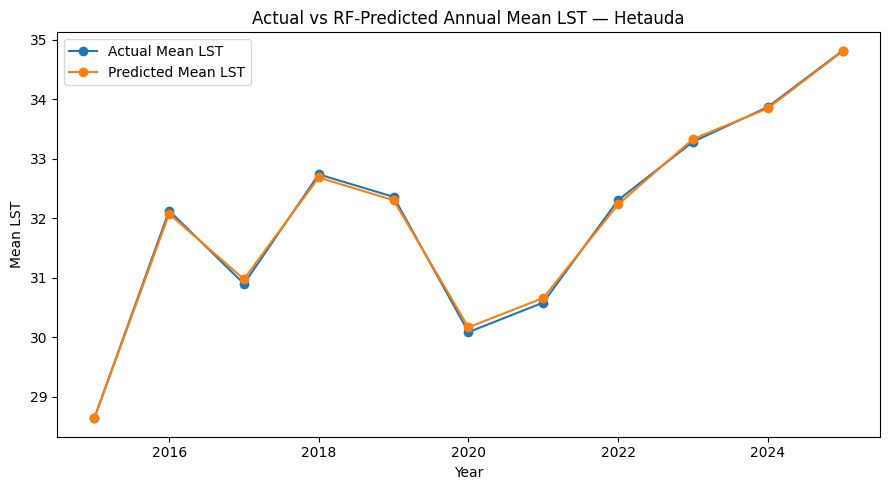

In [29]:
X_full = df[features]
df["Predicted_LST"] = rf.predict(X_full)

yearly_compare = df.groupby("Year")[["LST", "Predicted_LST"]].mean()
print(yearly_compare)

plt.figure(figsize=(9, 5))
plt.plot(yearly_compare.index, yearly_compare["LST"], marker="o", label="Actual Mean LST")
plt.plot(yearly_compare.index, yearly_compare["Predicted_LST"], marker="o", label="Predicted Mean LST")
plt.xlabel("Year")
plt.ylabel("Mean LST")
plt.title("Actual vs RF-Predicted Annual Mean LST — Hetauda")
plt.legend()
plt.tight_layout()
plt.show()

# Time-Series Forecasting (ARIMA)

### Aggregate Annual Mean LST

Year
2015    28.637912
2016    32.125783
2017    30.896822
2018    32.735659
2019    32.357641
2020    30.085121
2021    30.582045
2022    32.303114
2023    33.283109
2024    33.867396
2025    34.813797
Name: LST, dtype: float64


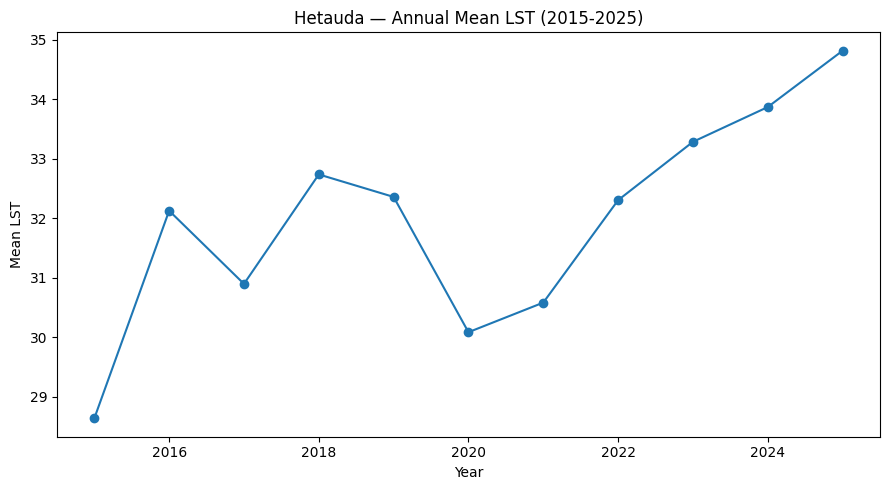

In [30]:
annual_lst = df.groupby("Year")["LST"].mean().sort_index()
print(annual_lst)

plt.figure(figsize=(9, 5))
plt.plot(annual_lst.index, annual_lst.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Mean LST")
plt.title("Hetauda — Annual Mean LST (2015-2025)")
plt.tight_layout()
plt.show()

##### Check Stationarity (Augmented Dickey-Fuller test)\n\nARIMA assumes the series is stationary (or becomes stationary after differencing). With 11 points this test has low power, but it's still worth checking — a p-value above 0.05 means we fail to reject the null of a unit root, i.e. the raw series is likely non-stationary and needs differencing (the `d` term in ARIMA(p,d,q)).

In [32]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(annual_lst.values)
print(f"ADF Statistic : {adf_result[0]:.3f}")
print(f"p-value       : {adf_result[1]:.3f}")
if adf_result[1] > 0.05:
    print("=> Series is likely non-stationary -> use d=1 (first differencing)")
else:
    print("=> Series is likely stationary -> d=0 may be sufficient")

ADF Statistic : -2.013
p-value       : 0.281
=> Series is likely non-stationary -> use d=1 (first differencing)


### Fit ARIMA

In [33]:
from statsmodels.tsa.arima.model import ARIMA

# order=(p, d, q). With only 11 annual points keep the model simple —
# (1,1,1) is a reasonable default; adjust based on the ADF test / AIC if needed.
model = ARIMA(annual_lst.values, order=(1, 1, 1))
fitted = model.fit()

print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   11
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -19.137
Date:                Mon, 20 Jul 2026   AIC                             44.273
Time:                        22:41:30   BIC                             45.181
Sample:                             0   HQIC                            43.277
                                 - 11                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3486      1.492     -0.234      0.815      -3.273       2.575
ma.L1          0.1289      1.926      0.067      0.947      -3.645       3.903
sigma2         2.6751      1.548      1.728      0.0

c:\Users\mccde\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mccde\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


### Forecast 2026-2028 with 95% Confidence Interval

In [34]:
forecast_years = [2026, 2027, 2028]

forecast_res = fitted.get_forecast(steps=len(forecast_years))
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

forecast_df = pd.DataFrame({
    "Year": forecast_years,
    "Forecast_LST": forecast_mean,
    "CI_Lower": conf_int[:, 0],
    "CI_Upper": conf_int[:, 1],
})

print(forecast_df)

   Year  Forecast_LST   CI_Lower   CI_Upper
0  2026     34.619530  31.413884  37.825175
1  2027     34.687259  30.621339  38.753178
2  2028     34.663646  29.756889  39.570403


### Plot: Historical LST Extending into Forecast

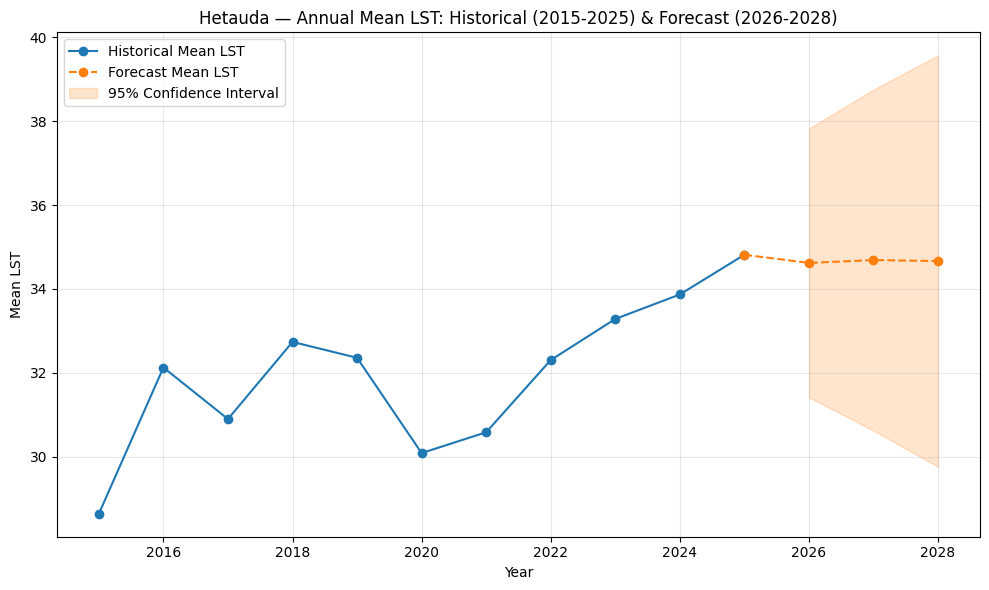

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(annual_lst.index, annual_lst.values, marker="o", color="tab:blue", label="Historical Mean LST")

connect_years = [annual_lst.index[-1]] + forecast_years
connect_values = [annual_lst.values[-1]] + list(forecast_mean)
plt.plot(connect_years, connect_values, marker="o", color="tab:orange", linestyle="--", label="Forecast Mean LST")

plt.fill_between(
    forecast_years,
    conf_int[:, 0],
    conf_int[:, 1],
    color="tab:orange",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Year")
plt.ylabel("Mean LST")
plt.title("Hetauda — Annual Mean LST: Historical (2015-2025) & Forecast (2026-2028)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()